In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from sklearn.model_selection import KFold, cross_val_predict
import os

ignorewarnings = True

In [13]:
df = pd.read_excel('../data_final_salada.xlsx')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         605 non-null    int64         
 1   day           605 non-null    int64         
 2   leaf_count    605 non-null    int64         
 3   plant_height  605 non-null    float64       
 4   leaf_length   605 non-null    float64       
 5   leaf_width    604 non-null    float64       
 6   date          605 non-null    datetime64[ns]
 7   ph            605 non-null    float64       
 8   ppm           605 non-null    float64       
 9   water_temp    605 non-null    float64       
 10  air_temp      605 non-null    float64       
 11  humidity      605 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 56.8 KB


In [15]:
df['leaf_width'].fillna(df['leaf_width'].mean(), inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   plant         605 non-null    int64         
 1   day           605 non-null    int64         
 2   leaf_count    605 non-null    int64         
 3   plant_height  605 non-null    float64       
 4   leaf_length   605 non-null    float64       
 5   leaf_width    605 non-null    float64       
 6   date          605 non-null    datetime64[ns]
 7   ph            605 non-null    float64       
 8   ppm           605 non-null    float64       
 9   water_temp    605 non-null    float64       
 10  air_temp      605 non-null    float64       
 11  humidity      605 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(3)
memory usage: 56.8 KB


In [17]:
def categorize_ppm(value):
    if value < 950:
        return "Very Low"
    elif value < 1050:
        return "Low"
    elif value < 1150:
        return "Medium"
    else:
        return "High"

df['ppm_category'] = df['ppm'].apply(categorize_ppm)

In [18]:
print(df[['ppm', 'ppm_category']].head(10))

          ppm ppm_category
0  888.677043     Very Low
1  888.677043     Very Low
2  888.677043     Very Low
3  888.677043     Very Low
4  888.677043     Very Low
5  888.677043     Very Low
6  888.677043     Very Low
7  888.677043     Very Low
8  888.677043     Very Low
9  888.677043     Very Low


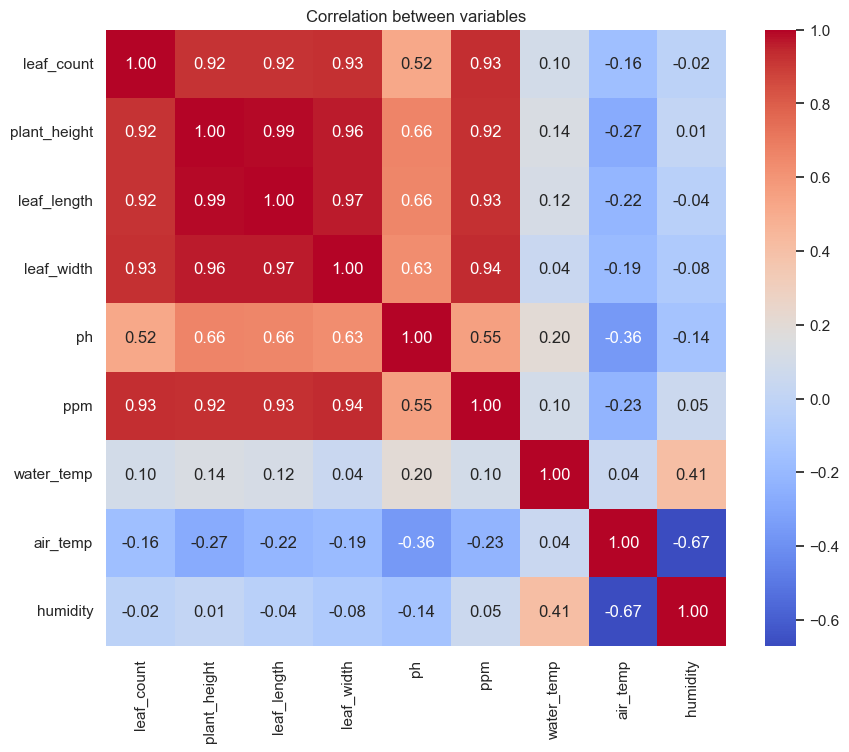

In [19]:
corr = df[['leaf_count','plant_height','leaf_length','leaf_width','ph','ppm','water_temp','air_temp','humidity']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between variables')
plt.show()

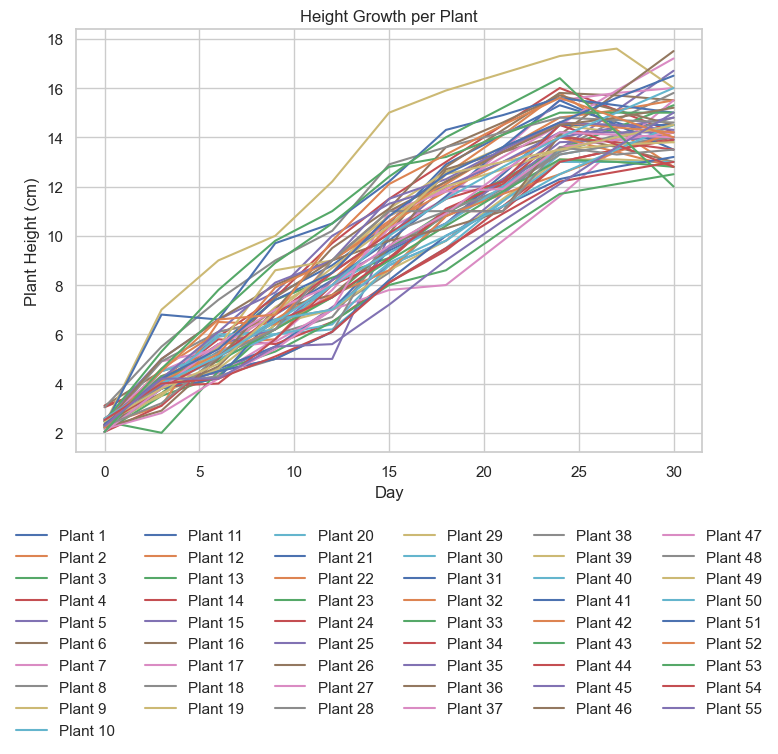

In [20]:
plt.figure(figsize=(8, 8))

for plant in df['plant'].dropna().unique():
    subset = df[df['plant'] == plant]
    plt.plot(subset['day'], subset['plant_height'], label=f'Plant {plant}')
    
plt.xlabel('Day')
plt.ylabel('Plant Height (cm)')
plt.title('Height Growth per Plant')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=6,
    frameon=False
)
plt.tight_layout()
plt.show()

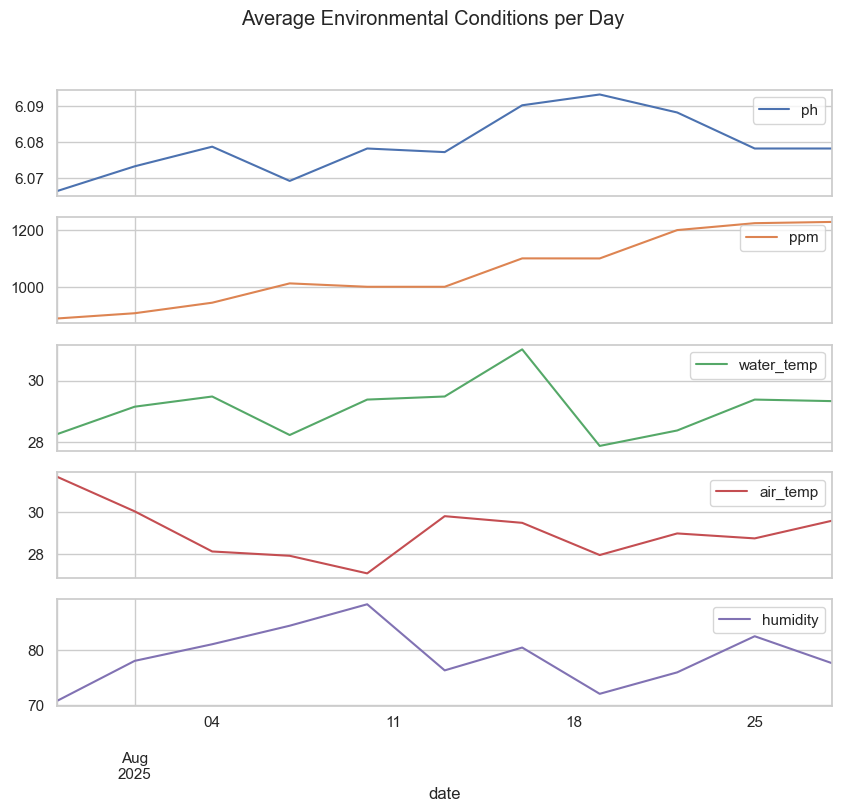

In [21]:
df.groupby('date')[['ph','ppm','water_temp','air_temp','humidity']].mean().plot(subplots=True, figsize=(10,8))
plt.suptitle('Average Environmental Conditions per Day')
plt.show()

In [22]:
numeric_cols = ['ph','ppm','water_temp','air_temp','humidity',
                'leaf_count','plant_height','leaf_length','leaf_width']
numeric_cols = [c for c in numeric_cols if c in df.columns]

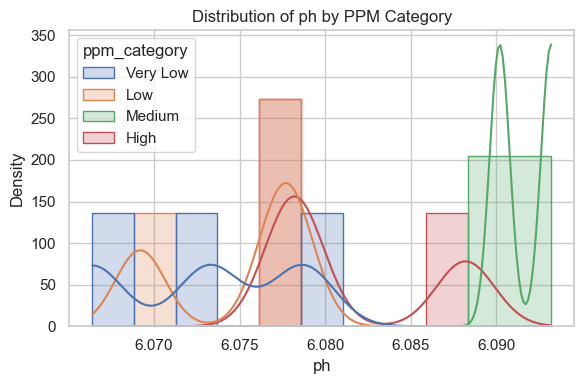

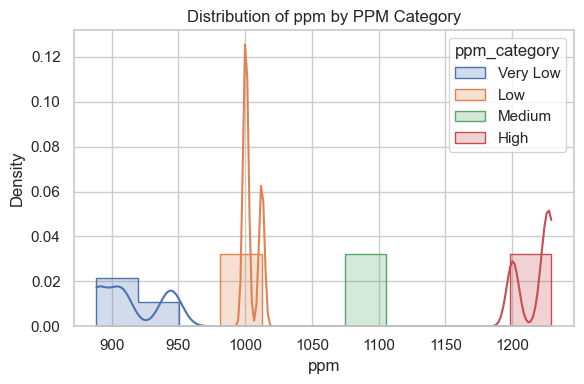

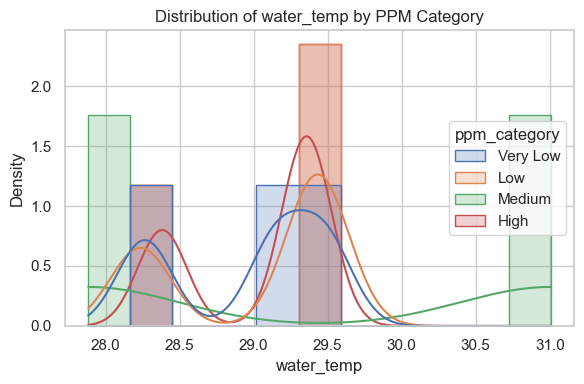

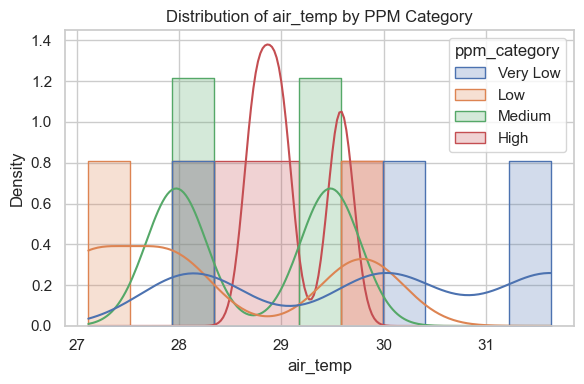

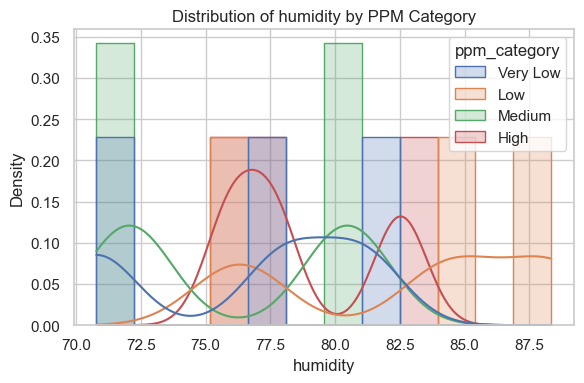

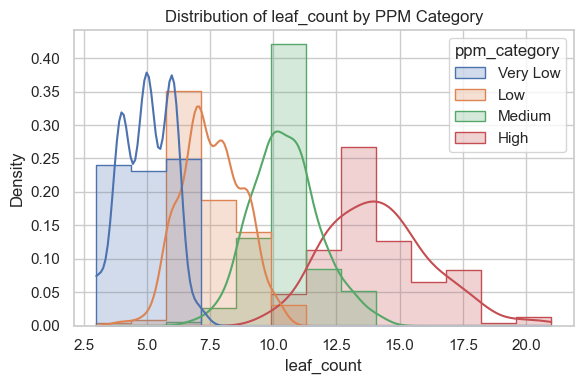

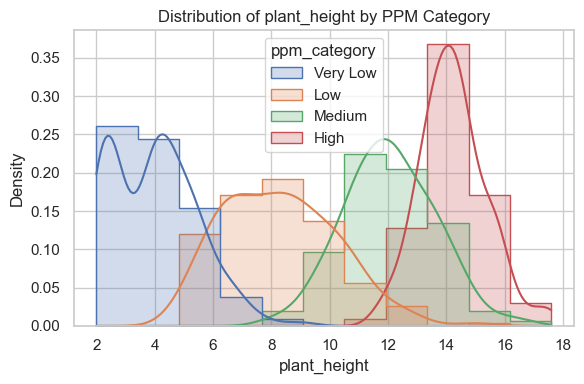

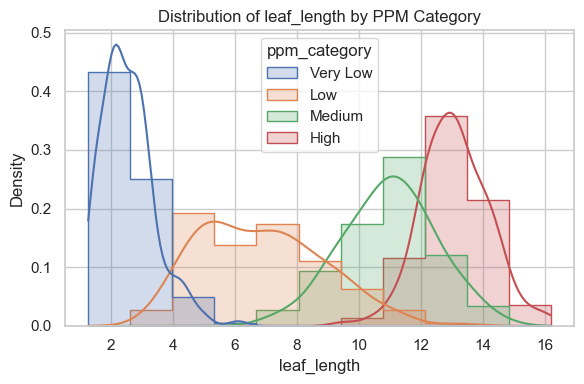

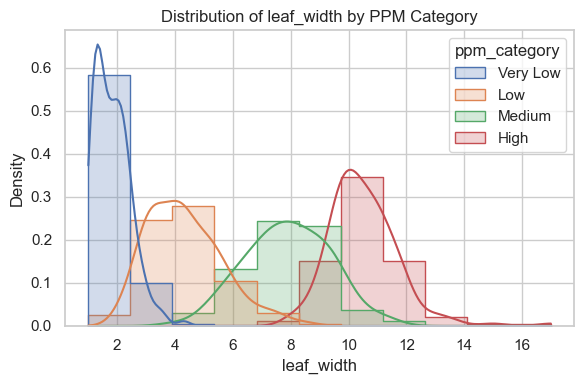

In [23]:
sns.set(style="whitegrid", context="notebook")

cat_order = [c for c in ["Very Low","Low","Medium","High"] if c in df['ppm_category'].unique()]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='ppm_category', element='step',
                 stat='density', common_norm=False, kde=True, hue_order=cat_order)
    plt.title(f'Distribution of {col} by PPM Category')
    plt.tight_layout()
    plt.show()

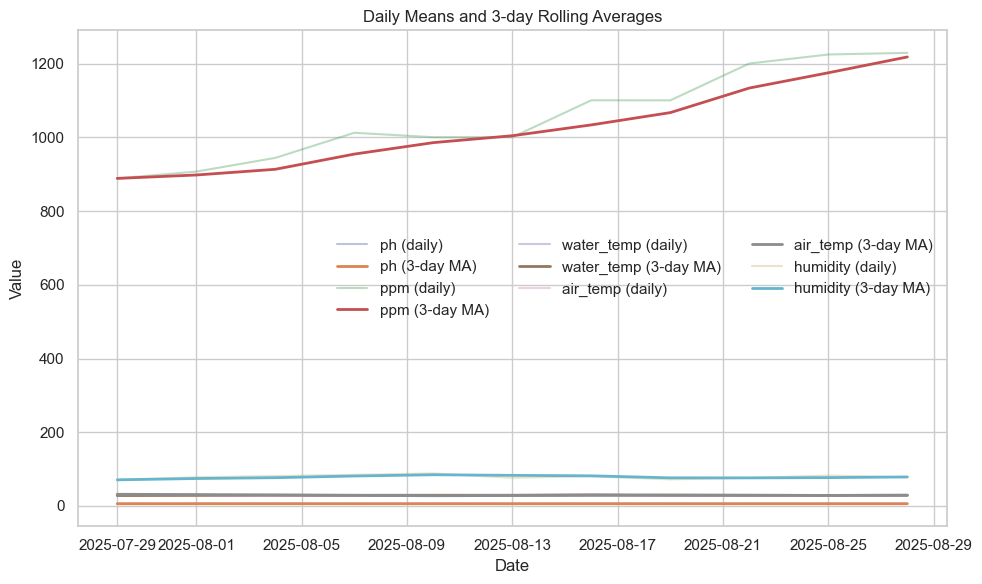

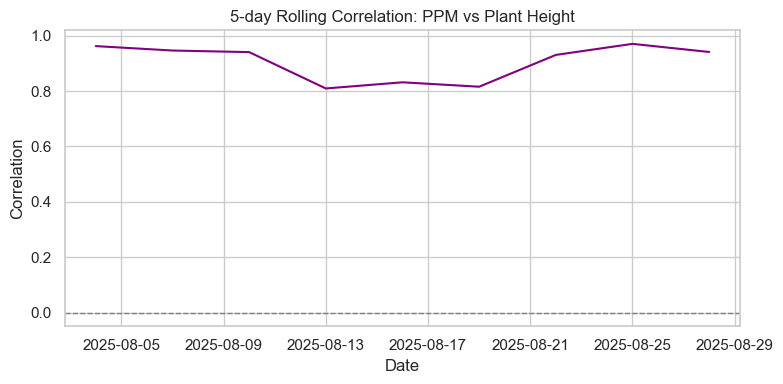

In [24]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    daily = df.groupby('date')[['ph','ppm','water_temp','air_temp','humidity',
                                'plant_height']].mean().sort_index()
    roll = daily.rolling(window=3, min_periods=1).mean()

    plt.figure(figsize=(10,6))
    for col in ['ph','ppm','water_temp','air_temp','humidity']:
        if col in daily.columns:
            plt.plot(daily.index, daily[col], alpha=0.4, label=f'{col} (daily)')
            plt.plot(roll.index, roll[col], linewidth=2, label=f'{col} (3-day MA)')
    plt.title('Daily Means and 3-day Rolling Averages')
    plt.xlabel('Date'); plt.ylabel('Value')
    plt.legend(ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()

    # Rolling correlation between PPM and Plant Height (daily means)
    if {'ppm','plant_height'}.issubset(daily.columns):
        rolling_corr = daily['ppm'].rolling(5, min_periods=3).corr(daily['plant_height'])
        plt.figure(figsize=(8,4))
        plt.plot(rolling_corr.index, rolling_corr, color='purple')
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.title('5-day Rolling Correlation: PPM vs Plant Height')
        plt.xlabel('Date'); plt.ylabel('Correlation')
        plt.tight_layout()
        plt.show()

### Semua sensor + tanaman

In [25]:
X = df[['ph', 'water_temp', 'air_temp', 'humidity',
        'leaf_count', 'plant_height', 'leaf_length', 'leaf_width']]

y = df['ppm']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [29]:
y_pred = model.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))

MAE: 3.6593480935166802
R2 : 0.9806465585460791


        Feature  Importance
4    leaf_count    0.706035
0            ph    0.124531
6   leaf_length    0.098803
7    leaf_width    0.049005
1    water_temp    0.008078
3      humidity    0.006930
2      air_temp    0.005663
5  plant_height    0.000953


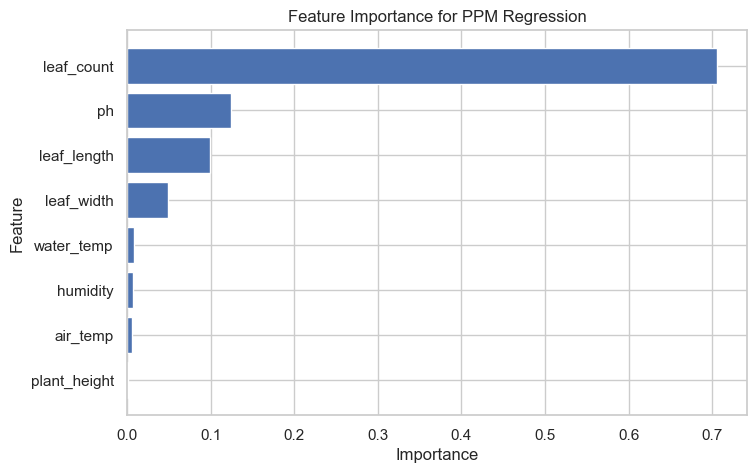

In [30]:
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Regression')
plt.gca().invert_yaxis()
plt.show()

In [34]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [37]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res_mae = cross_val_score(pipeline, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_res_r2 = cross_val_score(pipeline, X, y, cv=cv, scoring='r2', n_jobs=-1)
print(f"CV MAE: {-cv_res_mae.mean():.4f} ± {cv_res_mae.std():.4f}")
print(f"CV R2 : {cv_res_r2.mean():.4f} ± {cv_res_r2.std():.4f}")

CV MAE: 4.6649 ± 1.7992
CV R2 : 0.9799 ± 0.0186


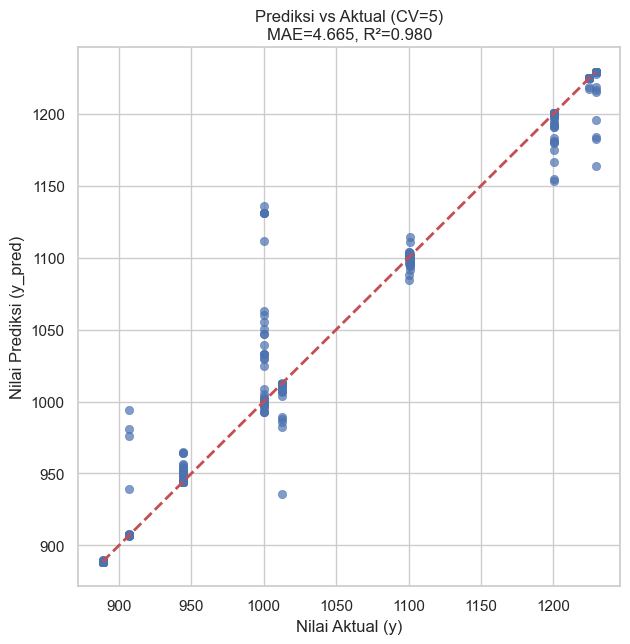

In [ ]:
y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)

mae = mean_absolute_error(y, y_pred_cv)
r2 = r2_score(y, y_pred_cv)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y, y=y_pred_cv, alpha=0.7, edgecolor=None)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Nilai Aktual (y)")
plt.ylabel("Nilai Prediksi (y_pred)")
plt.title(f"Prediksi vs Aktual (CV=5)\nMAE={mae:.3f}, R²={r2:.3f}")
plt.grid(True)
plt.show()

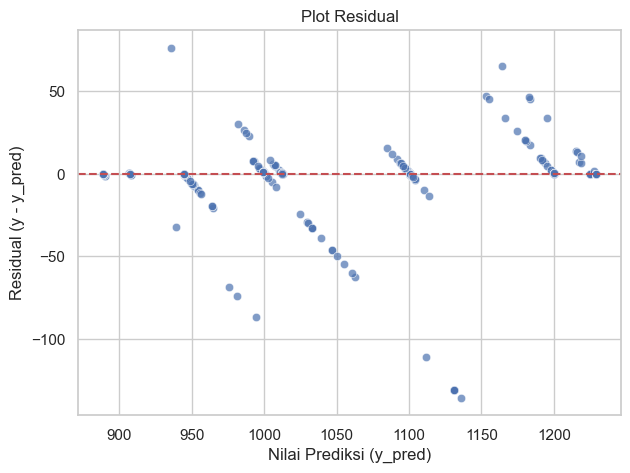

In [44]:
residuals = y - y_pred_cv
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_cv, y=residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Nilai Prediksi (y_pred)")
plt.ylabel("Residual (y - y_pred)")
plt.title("Plot Residual")
plt.grid(True)
plt.show()

### Hanya Sensor

In [46]:
X2 = df[['ph', 'water_temp', 'air_temp', 'humidity']]

y2 = df['ppm']

In [47]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

In [48]:
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

In [49]:
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train2_scaled, y_train2)

RandomForestRegressor(random_state=42)

In [50]:
y_pred2 = model2.predict(X_test2_scaled)
print("MAE:", mean_absolute_error(y_test2, y_pred2))
print("R2 :", r2_score(y_test2, y_pred2))

MAE: 1.3823569883403091e-12
R2 : 1.0


      Feature  Importance
0          ph    0.493496
2    air_temp    0.420887
1  water_temp    0.052772
3    humidity    0.032845


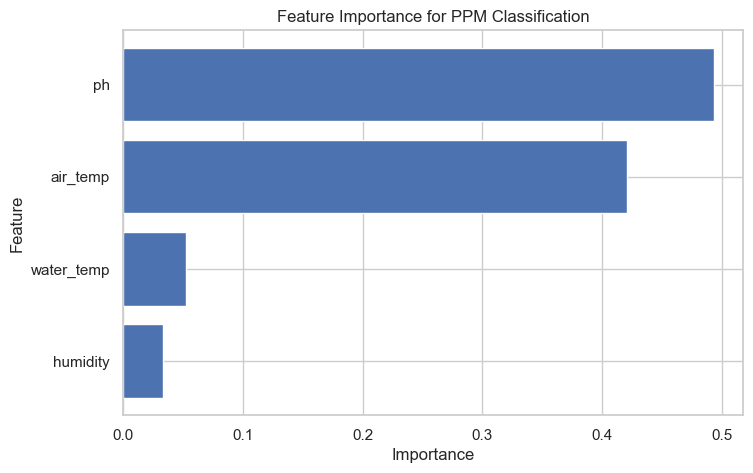

In [ ]:
importance2 = model2.feature_importances_
feature_importance2 = pd.DataFrame({
    'Feature': X2.columns,
    'Importance': importance2
}).sort_values(by='Importance', ascending=False)

print(feature_importance2)

plt.figure(figsize=(8,5))
plt.barh(feature_importance2['Feature'], feature_importance2['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for PPM Classification')
plt.gca().invert_yaxis()
plt.show()

In [52]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [53]:
cv2 = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res_mae2 = cross_val_score(pipeline2, X2, y2, cv=cv2, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_res_r22 = cross_val_score(pipeline2, X2, y2, cv=cv2, scoring='r2', n_jobs=-1)
print(f"CV MAE: {-cv_res_mae2.mean():.4f} ± {cv_res_mae2.std():.4f}")
print(f"CV R2 : {cv_res_r22.mean():.4f} ± {cv_res_r22.std():.4f}")

CV MAE: 0.0000 ± 0.0000
CV R2 : 1.0000 ± 0.0000


### Penggunaan Model

In [55]:
pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=5,
                                       random_state=42))])

In [56]:
pipeline2.fit(X2, y2)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=5,
                                       random_state=42))])

In [54]:
sample_reg = {
    'ph': 6.5,
    'water_temp': 22.0,
    'air_temp': 25.0,
    'humidity': 60.0,
    'leaf_count': 8,
    'plant_height': 12.5,
    'leaf_length': 6.0,
    'leaf_width': 2.5
}

# Jika ingin hanya sensor:
sample_sensor = {
    'ph': 6.5,
    'water_temp': 22.0,
    'air_temp': 25.0,
    'humidity': 60.0
}

In [60]:
sample_df = pd.DataFrame([sample_reg])
sample_df2 = pd.DataFrame([sample_sensor])

In [59]:
predicted_value = pipeline.predict(sample_df)[0]

print(f"Hasil prediksi untuk sample_reg: {predicted_value:.4f}")

Hasil prediksi untuk sample_reg: 1077.5146


In [62]:
predicted_value2 = pipeline2.predict(sample_df2)[0]

print(f"Hasil prediksi untuk sample_sensor: {predicted_value2:.4f}")

Hasil prediksi untuk sample_sensor: 1100.4793


In [63]:
save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

In [64]:
model_path = os.path.join(save_dir, 'model_pipeline_all.pkl')
joblib.dump(pipeline, model_path)
model_path2 = os.path.join(save_dir, 'model_pipeline_sensor.pkl')
joblib.dump(pipeline2, model_path2)

['models\\model_pipeline_sensor.pkl']